<a href="https://colab.research.google.com/github/Dracarys38/Machyne-navchanya/blob/main/%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0_%D1%80%D0%BE%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%9612_%D0%9C%D0%9D%2C_%D0%9F%D0%BE%D1%81%D1%82%D0%B5%D0%BB%D1%8C%D0%BD%D1%8F%D0%BA_%D0%86%D0%B3%D0%BE%D1%80_%D0%A1%D0%B5%D1%80%D0%B3%D1%96%D0%B9%D0%BE%D0%B2%D0%B8%D1%87_%D0%A4%D0%86%D0%A2_3_15%2C_10_%D0%B2%D0%B0%D1%80%D1%96%D0%B0%D0%BD%D1%82.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kagglehub -q

## Імпорт бібліотек

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os, random, cv2, warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# Відтворюваність результатів
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.19.0
GPU available: True



#  ЗАВДАННЯ 1: Fashion MNIST — Класифікація типів одягу


## 1.1 Завантаження та підготовка даних

In [ ]:
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = keras.datasets.fashion_mnist.load_data()

CLASS_NAMES_FASHION = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

print(f'Train: {X_train_raw.shape}, Test: {X_test_raw.shape}')
print(f'Кількість класів: {len(CLASS_NAMES_FASHION)}')

Train: (60000, 28, 28), Test: (10000, 28, 28)
Кількість класів: 10


In [ ]:
X_train_f = X_train_raw.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test_f  = X_test_raw.reshape(-1, 28, 28, 1).astype('float32') / 255.0

X_train_f, X_val_f, y_train_f, y_val_f = train_test_split(
    X_train_f, y_train_raw, test_size=0.15, random_state=SEED, stratify=y_train_raw
)

y_test_f = y_test_raw

print(f'Train: {X_train_f.shape}  |  Val: {X_val_f.shape}  |  Test: {X_test_f.shape}')

Train: (51000, 28, 28, 1)  |  Val: (9000, 28, 28, 1)  |  Test: (10000, 28, 28, 1)


## 1.2 Візуалізація прикладів датасету

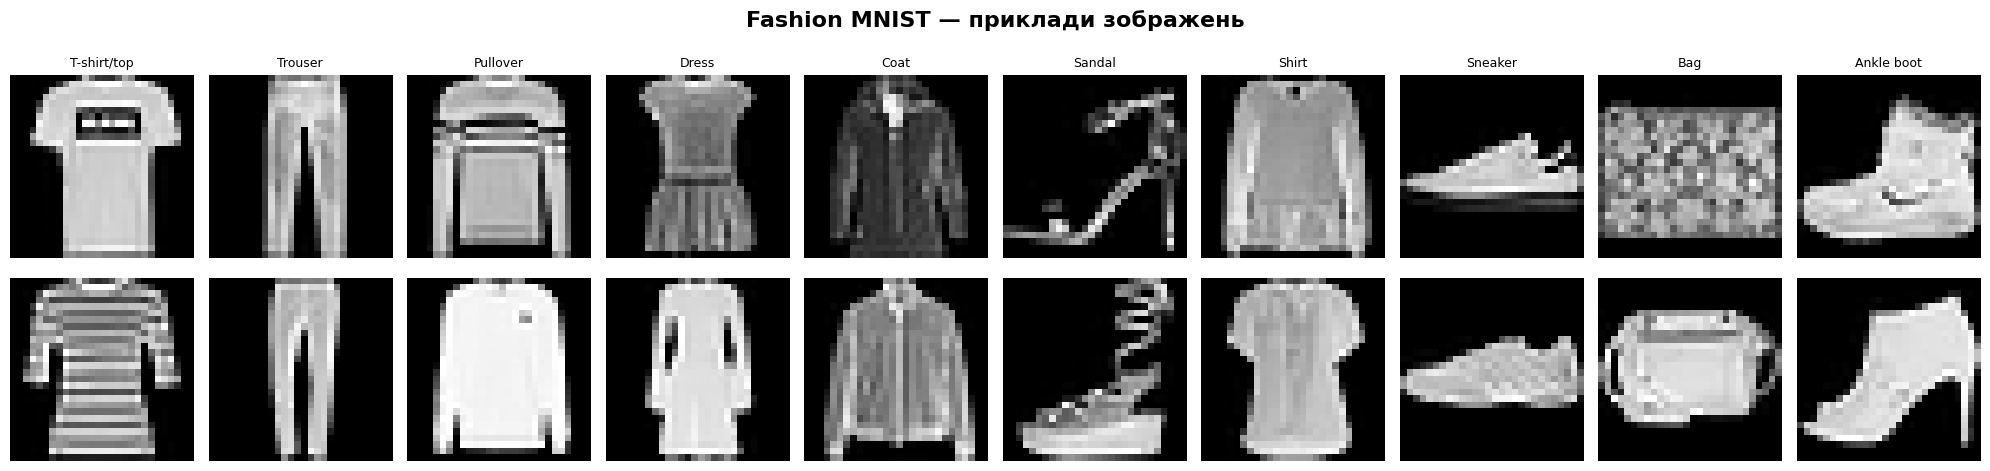

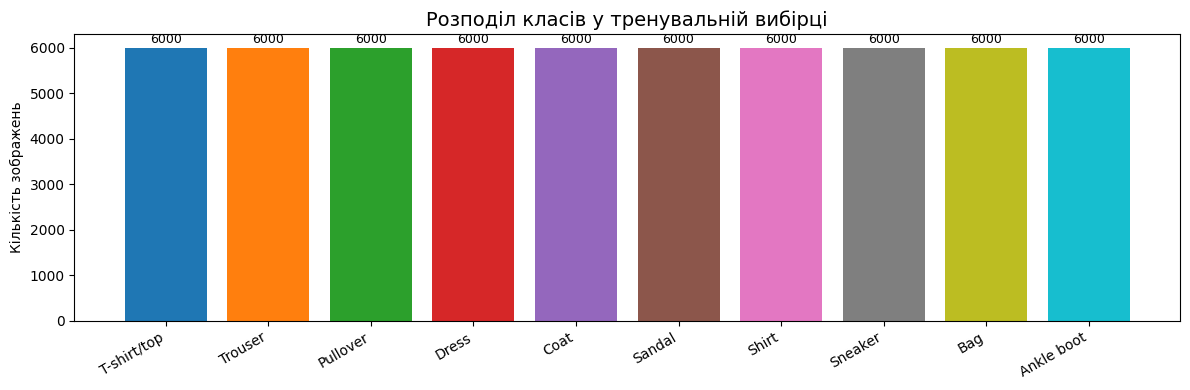

In [ ]:
fig, axes = plt.subplots(2, 10, figsize=(20, 5))
fig.suptitle('Fashion MNIST — приклади зображень', fontsize=16, fontweight='bold')

for cls in range(10):
    idx = np.where(y_train_raw == cls)[0][0]
    axes[0, cls].imshow(X_train_raw[idx], cmap='gray')
    axes[0, cls].set_title(CLASS_NAMES_FASHION[cls], fontsize=9)
    axes[0, cls].axis('off')

    idx2 = np.where(y_train_raw == cls)[0][5]
    axes[1, cls].imshow(X_train_raw[idx2], cmap='gray')
    axes[1, cls].axis('off')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
unique, counts = np.unique(y_train_raw, return_counts=True)
bars = ax.bar([CLASS_NAMES_FASHION[i] for i in unique], counts, color=plt.cm.tab10.colors)
ax.set_title('Розподіл класів у тренувальній вибірці', fontsize=14)
ax.set_ylabel('Кількість зображень')
ax.set_xticklabels([CLASS_NAMES_FASHION[i] for i in unique], rotation=30, ha='right')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(count), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 1.3 Побудова архітектури CNN

In [ ]:
def build_fashion_cnn(input_shape=(28, 28, 1), num_classes=10):
    model = models.Sequential([

        layers.Conv2D(32, (3, 3), padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(32, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),


        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.30),


        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.35),


        layers.GlobalAveragePooling2D(),
        layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ], name='Fashion_CNN')
    return model

model_fashion = build_fashion_cnn()
model_fashion.summary()

Model: "Fashion_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │             

 Total params: 176,746 (690.41 KB)

 Trainable params: 175,594 (685.91 KB)

 Non-trainable params: 1,152 (4.50 KB)

## 1.4 Компіляція та навчання з колбеками

In [ ]:

datagen_fashion = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen_fashion.fit(X_train_f)


model_fashion.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


cb_early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1
)
cb_reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1
)
cb_checkpoint = callbacks.ModelCheckpoint(
    'best_fashion_cnn.keras', save_best_only=True, monitor='val_accuracy', verbose=0
)

BATCH_SIZE = 64
EPOCHS     = 50

history_fashion = model_fashion.fit(
    datagen_fashion.flow(X_train_f, y_train_f, batch_size=BATCH_SIZE, seed=SEED),
    steps_per_epoch=len(X_train_f) // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val_f, y_val_f),
    callbacks=[cb_early_stop, cb_reduce_lr, cb_checkpoint],
    verbose=1
)

Epoch 1/50
796/796 ━━━━━━━━━━━━━━━━━━━━ 52s 40ms/step - accuracy: 0.6910 - loss: 0.8530 - val_accuracy: 0.7874 - val_loss: 0.5979 - learning_rate: 0.0010
Epoch 2/50
796/796 ━━━━━━━━━━━━━━━━━━━━ 1s 989us/step - accuracy: 0.8594 - loss: 0.4056 - val_accuracy: 0.7829 - val_loss: 0.6154 - learning_rate: 0.0010
Epoch 3/50
796/796 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.7913 - loss: 0.5791 - val_accuracy: 0.8431 - val_loss: 0.4343 - learning_rate: 0.0010
Epoch 4/50
796/796 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8281 - loss: 0.4617 - val_accuracy: 0.8423 - val_loss: 0.4363 - learning_rate: 0.0010
Epoch 5/50
796/796 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.8194 - loss: 0.5085 - val_accuracy: 0.8508 - val_loss: 0.4238 - learning_rate: 0.0010
Epoch 6/50
796/796 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7500 - loss: 0.5812 - val_accuracy: 0.8586 - val_loss: 0.4077 - learning_rate: 0.0010
Epoch 7/50
796/796 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.8366 - loss:

## 1.5 Криві навчання

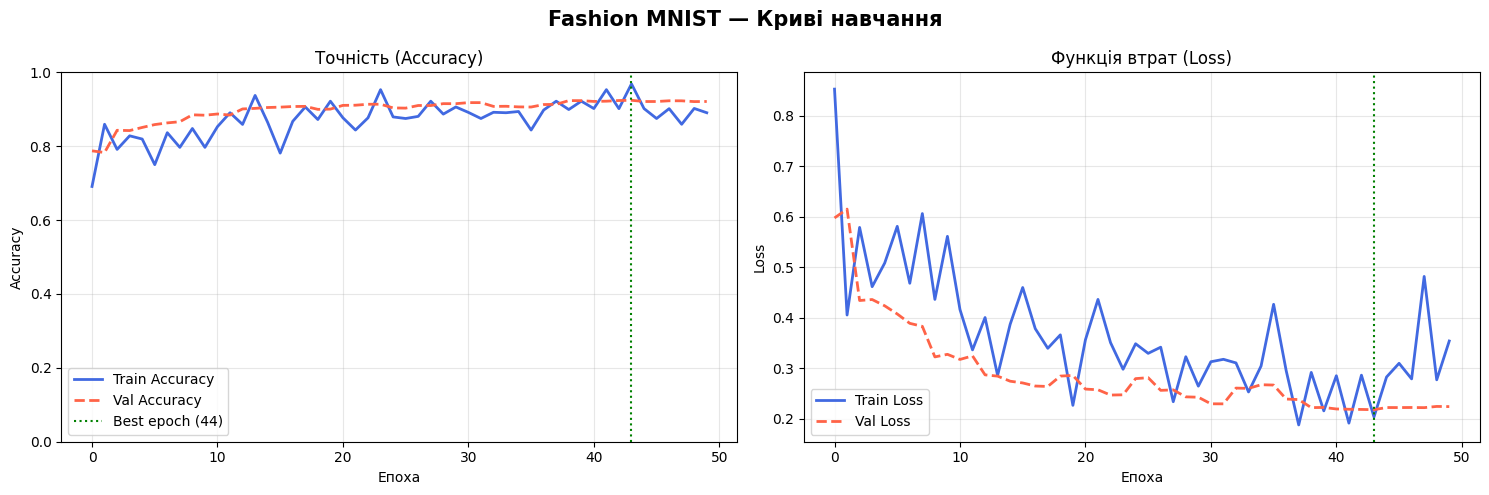

In [ ]:
def plot_training_curves(history, title='Криві навчання'):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(title, fontsize=15, fontweight='bold')


    axes[0].plot(history.history['accuracy'],     label='Train Accuracy', linewidth=2, color='royalblue')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   linewidth=2, color='tomato', linestyle='--')
    best_epoch = np.argmax(history.history['val_accuracy'])
    axes[0].axvline(best_epoch, color='green', linestyle=':', label=f'Best epoch ({best_epoch+1})')
    axes[0].set_title('Точність (Accuracy)')
    axes[0].set_xlabel('Епоха')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    axes[0].set_ylim([0, 1])


    axes[1].plot(history.history['loss'],     label='Train Loss', linewidth=2, color='royalblue')
    axes[1].plot(history.history['val_loss'], label='Val Loss',   linewidth=2, color='tomato', linestyle='--')
    axes[1].axvline(np.argmin(history.history['val_loss']), color='green', linestyle=':')
    axes[1].set_title('Функція втрат (Loss)')
    axes[1].set_xlabel('Епоха')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


    if 'lr' in history.history:
        plt.figure(figsize=(8, 3))
        plt.plot(history.history['lr'], color='purple', linewidth=2)
        plt.title('Швидкість навчання (Learning Rate)')
        plt.xlabel('Епоха')
        plt.ylabel('LR')
        plt.yscale('log')
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

plot_training_curves(history_fashion, title='Fashion MNIST — Криві навчання')

## 1.6 Оцінка моделі на тестовій вибірці

In [ ]:
test_loss, test_acc = model_fashion.evaluate(X_test_f, y_test_f, verbose=0)
print(f'\n{'='*50}')
print(f'  Test Loss:     {test_loss:.4f}')
print(f'  Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'{'='*50}')

y_pred_f = np.argmax(model_fashion.predict(X_test_f, verbose=0), axis=1)

print('\nЗвіт класифікації:')
print(classification_report(y_test_f, y_pred_f, target_names=CLASS_NAMES_FASHION))


  Test Loss:     0.2421
  Test Accuracy: 0.9169 (91.69%)

Звіт класифікації:
              precision    recall  f1-score   support

 T-shirt/top       0.90      0.85      0.87      1000
     Trouser       1.00      0.98      0.99      1000
    Pullover       0.93      0.85      0.89      1000
       Dress       0.94      0.89      0.91      1000
        Coat       0.83      0.90      0.86      1000
      Sandal       0.97      0.99      0.98      1000
       Shirt       0.73      0.80      0.76      1000
     Sneaker       0.94      0.98      0.96      1000
         Bag       0.99      0.99      0.99      1000
  Ankle boot       0.99      0.94      0.96      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



## 1.7 Матриця помилок

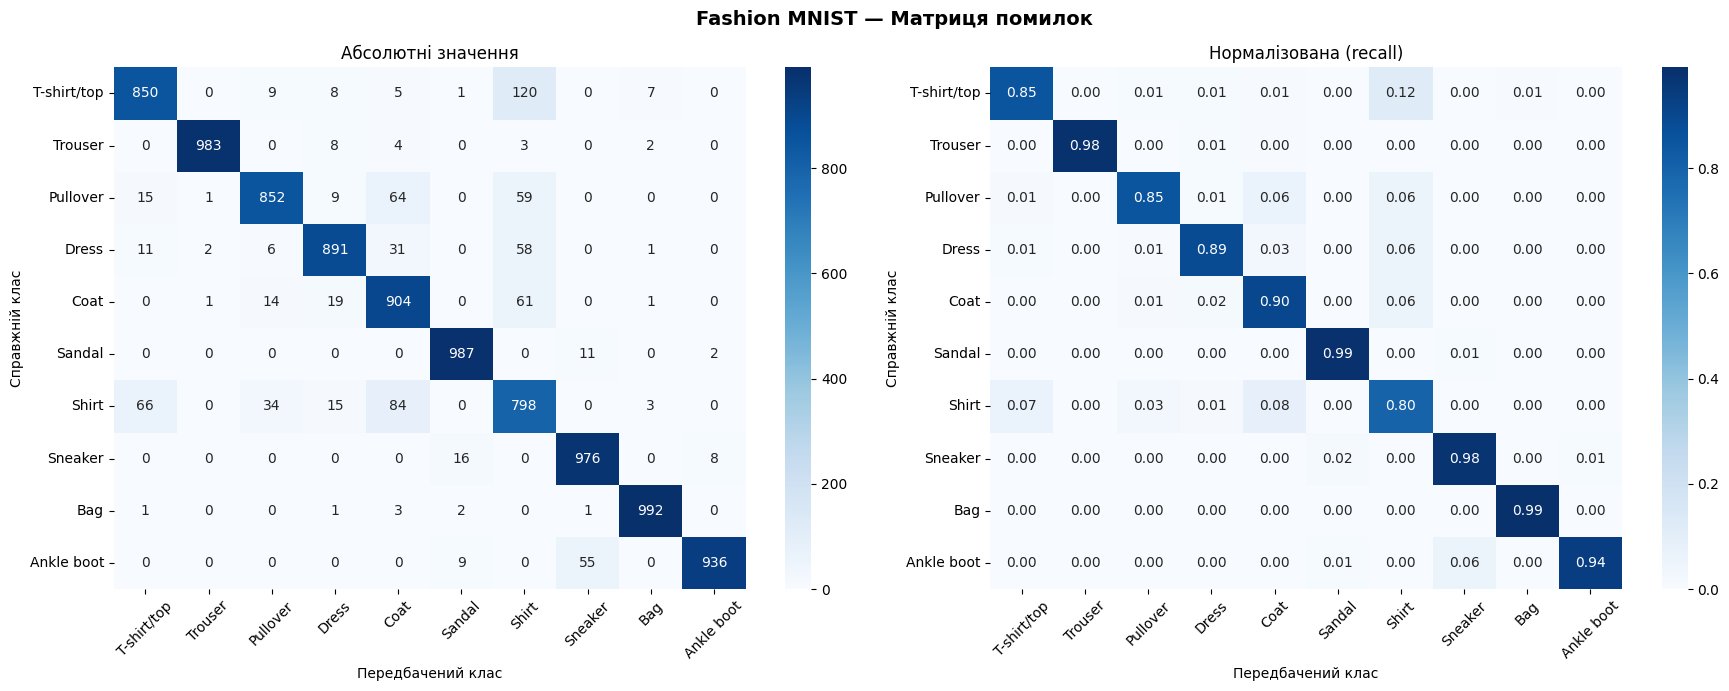

In [ ]:
cm = confusion_matrix(y_test_f, y_pred_f)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Fashion MNIST — Матриця помилок', fontsize=14, fontweight='bold')

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2f'],
    ['Абсолютні значення', 'Нормалізована (recall)']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                xticklabels=CLASS_NAMES_FASHION, yticklabels=CLASS_NAMES_FASHION)
    ax.set_title(title)
    ax.set_ylabel('Справжній клас')
    ax.set_xlabel('Передбачений клас')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

## 1.8 Візуалізація класифікації — правильні та помилкові передбачення

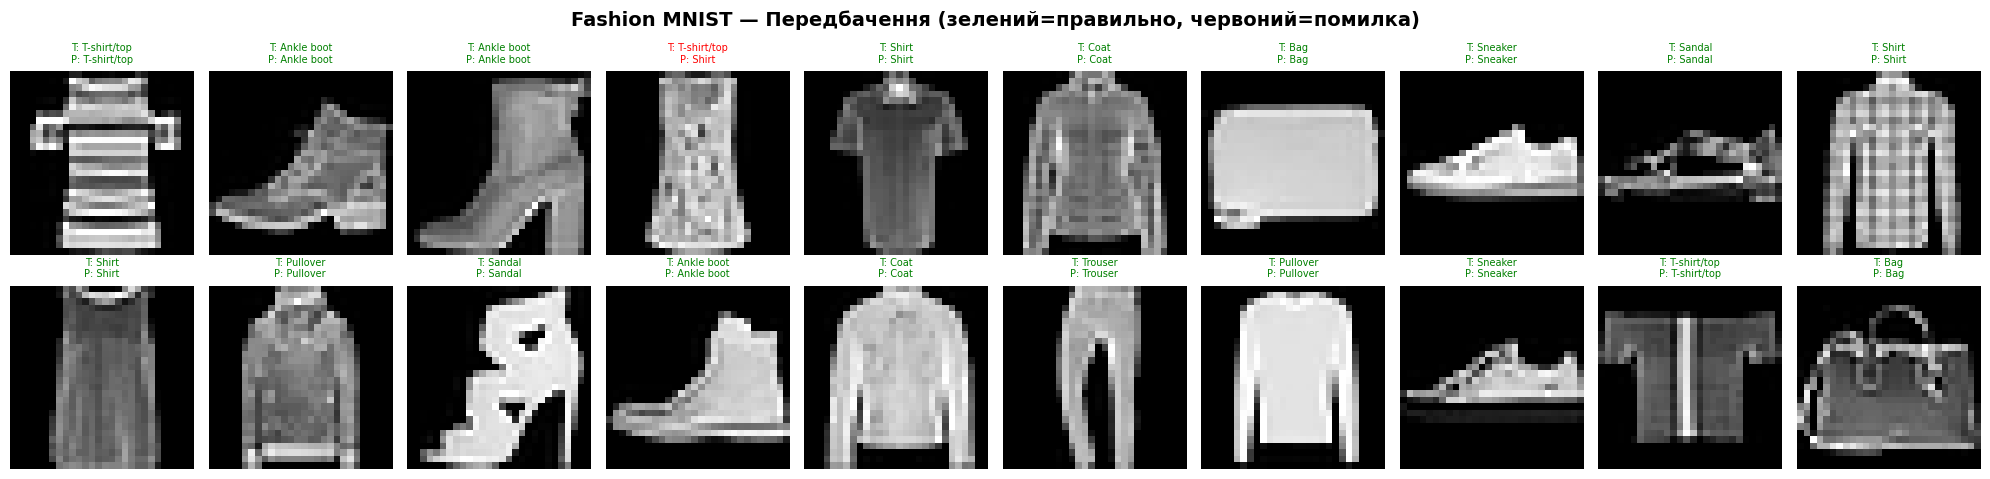

In [ ]:
def plot_predictions(X, y_true, y_pred, class_names, n=20, title='Передбачення моделі'):
    indices = random.sample(range(len(X)), n)
    cols = 10
    rows = n // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2.5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    for i, idx in enumerate(indices):
        ax = axes[i // cols][i % cols]
        img = X[idx].squeeze()
        ax.imshow(img, cmap='gray')
        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]
        color = 'green' if y_true[idx] == y_pred[idx] else 'red'
        ax.set_title(f'T: {true_label}\nP: {pred_label}', fontsize=7, color=color)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

plot_predictions(X_test_f, y_test_f, y_pred_f, CLASS_NAMES_FASHION,
                 n=20, title='Fashion MNIST — Передбачення (зелений=правильно, червоний=помилка)')

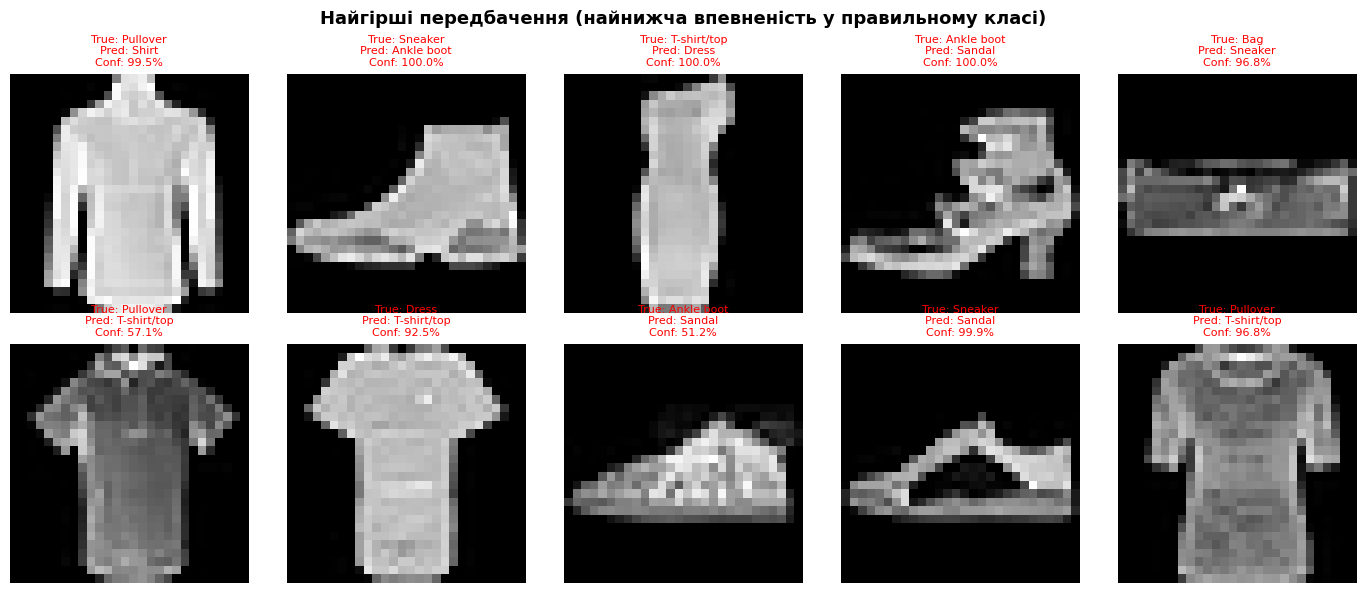

In [ ]:

y_prob_f = model_fashion.predict(X_test_f, verbose=0)
correct_probs = y_prob_f[np.arange(len(y_test_f)), y_test_f]
wrong_mask    = y_pred_f != y_test_f
wrong_indices = np.where(wrong_mask)[0]
worst_indices = wrong_indices[np.argsort(correct_probs[wrong_mask])][:10]

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Найгірші передбачення (найнижча впевненість у правильному класі)', fontsize=13, fontweight='bold')
for ax, idx in zip(axes.flatten(), worst_indices):
    ax.imshow(X_test_f[idx].squeeze(), cmap='gray')
    ax.set_title(
        f'True: {CLASS_NAMES_FASHION[y_test_f[idx]]}\n'
        f'Pred: {CLASS_NAMES_FASHION[y_pred_f[idx]]}\n'
        f'Conf: {y_prob_f[idx, y_pred_f[idx]]*100:.1f}%',
        fontsize=8, color='red'
    )
    ax.axis('off')
plt.tight_layout()
plt.show()

## 1.9 Візуалізація фічмап (feature maps)

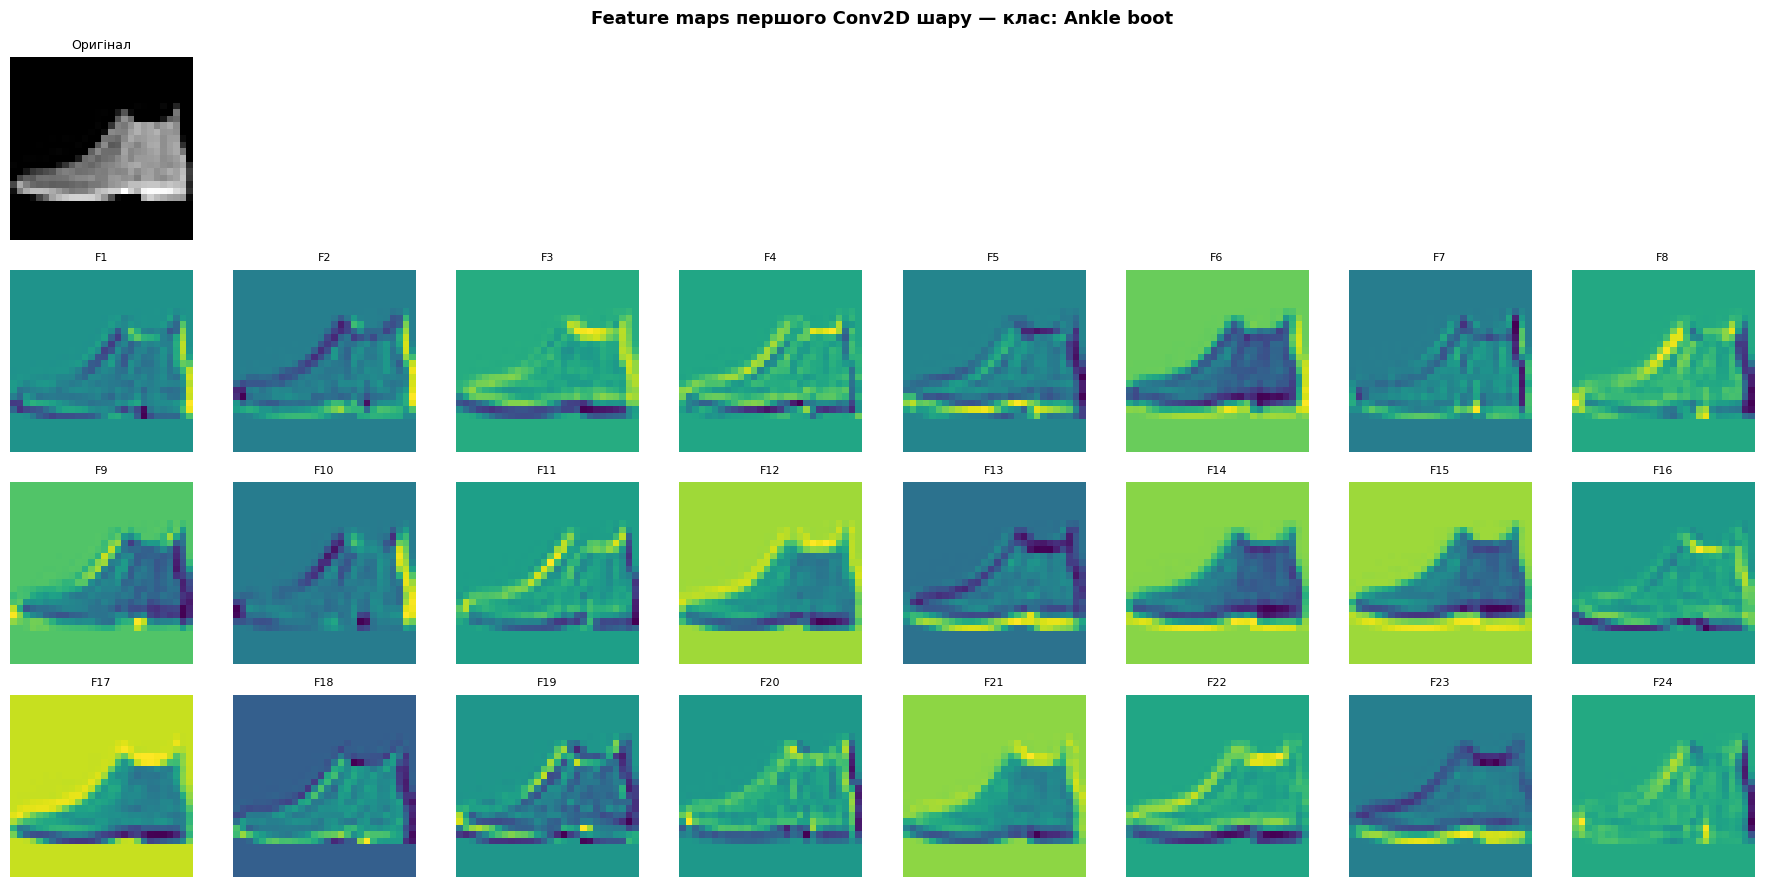

In [ ]:
sample_img = X_test_f[0:1]

_ = model_fashion(sample_img, training=False)

layer_outputs = [layer.output for layer in model_fashion.layers if isinstance(layer, layers.Conv2D)]
activation_model = models.Model(inputs=model_fashion.inputs, outputs=layer_outputs[:3])

activations = activation_model.predict(sample_img, verbose=0)

fig, axes = plt.subplots(4, 8, figsize=(18, 9))
fig.suptitle(f'Feature maps першого Conv2D шару — клас: {CLASS_NAMES_FASHION[y_test_f[0]]}',
             fontsize=13, fontweight='bold')

axes[0, 0].imshow(sample_img[0].squeeze(), cmap='gray')
axes[0, 0].set_title('Оригінал', fontsize=9)
axes[0, 0].axis('off')
for i in range(1, 8):
    axes[0, i].axis('off')

for i in range(min(24, activations[0].shape[-1])):
    r, c = (i // 8) + 1, i % 8
    axes[r, c].imshow(activations[0][0, :, :, i], cmap='viridis')
    axes[r, c].set_title(f'F{i+1}', fontsize=8)
    axes[r, c].axis('off')

plt.tight_layout()
plt.show()


# ЗАВДАННЯ 2: GTSRB — Розпізнавання дорожніх знаків


## 2.1 Завантаження датасету GTSRB

In [ ]:
import kagglehub

path = kagglehub.dataset_download('meowmeowmeowmeowmeow/gtsrb-german-traffic-sign')
print('Path to dataset files:', path)


for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    if level <= 2:
        indent = ' ' * 2 * level
        print(f'{indent}{os.path.basename(root)}/')
        if level == 2:
            subindent = ' ' * 2 * (level + 1)
            print(f'{subindent}({len(files)} files)')

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Path to dataset files: /kaggle/input/gtsrb-german-traffic-sign
gtsrb-german-traffic-sign/
  Meta/
  meta/
  Test/
  test/
  Train/
    7/
      (1440 files)
    17/
      (1110 files)
    19/
      (210 files)
    22/
      (390 files)
    2/
      (2250 files)
    35/
      (1200 files)
    23/
      (510 files)
    10/
      (2010 files)
    5/
      (1860 files)
    36/
      (390 files)
    20/
      (360 files)
    27/
      (240 files)
    41/
      (240 files)
    39/
      (300 files)
    32/
      (240 files)
    25/
      (1500 files)
    42/
      (240 files)
    8/
      (1410 files)
    38/
      (2070 files)
    12/
      (2100 files)
    0/
      (210 files)
    31/
      (780 files)
    34/
      (420 files)
    18/
      (1200 files)
    28/
      (540 files)
    16/
      (420 files)
    13/
      (2160 files)
    26/
      (600 files)
    15/
      (630 files)
    3/
      (1410 files)
  

In [ ]:

CLASS_NAMES_GTSRB = [
    'Speed limit (20km/h)',    'Speed limit (30km/h)',    'Speed limit (50km/h)',
    'Speed limit (60km/h)',    'Speed limit (70km/h)',    'Speed limit (80km/h)',
    'End of speed limit',      'Speed limit (100km/h)',   'Speed limit (120km/h)',
    'No passing',              'No passing >3.5t',        'Right-of-way',
    'Priority road',           'Yield',                   'Stop',
    'No vehicles',             'Vehicles >3.5t prohibited','No entry',
    'General caution',         'Dangerous curve left',    'Dangerous curve right',
    'Double curve',            'Bumpy road',              'Slippery road',
    'Road narrows right',      'Road work',               'Traffic signals',
    'Pedestrians',             'Children crossing',       'Bicycles crossing',
    'Beware of ice/snow',      'Wild animals crossing',   'End restrictions',
    'Turn right ahead',        'Turn left ahead',         'Ahead only',
    'Go straight or right',    'Go straight or left',     'Keep right',
    'Keep left',               'Roundabout mandatory',    'End of no passing',
    'End no passing >3.5t'
]
NUM_CLASSES_GTSRB = 43
IMG_SIZE_GTSRB    = 48

print(f'Кількість класів: {NUM_CLASSES_GTSRB}')

Кількість класів: 43


In [ ]:
def load_gtsrb_data(data_path, img_size=48, max_per_class=None):
    """Завантажує GTSRB зображення з папок по класах."""
    X, y = [], []


    train_path = None
    for root, dirs, files in os.walk(data_path):
        if 'Train' in dirs:
            train_path = os.path.join(root, 'Train')
            break
        if os.path.basename(root) == 'Train':
            train_path = root
            break

    if train_path is None:

        for root, dirs, files in os.walk(data_path):
            if any(d.isdigit() and int(d) < 43 for d in dirs):
                train_path = root
                break

    print(f'Train path: {train_path}')

    class_folders = sorted([d for d in os.listdir(train_path)
                             if os.path.isdir(os.path.join(train_path, d))])

    for folder in class_folders:
        class_id  = int(folder)
        class_dir = os.path.join(train_path, folder)
        images    = [f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.ppm'))]
        if max_per_class:
            images = random.sample(images, min(max_per_class, len(images)))
        for img_name in images:
            img_path = os.path.join(class_dir, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (img_size, img_size))
            X.append(img)
            y.append(class_id)

    return np.array(X, dtype='uint8'), np.array(y, dtype='int32')


print('Завантаження даних GTSRB...')
X_gtsrb_raw, y_gtsrb_raw = load_gtsrb_data(path, img_size=IMG_SIZE_GTSRB)
print(f'Завантажено: {X_gtsrb_raw.shape}, мітки: {y_gtsrb_raw.shape}')
print(f'Унікальних класів: {len(np.unique(y_gtsrb_raw))}')

Завантаження даних GTSRB...
Train path: /kaggle/input/gtsrb-german-traffic-sign/Train
Завантажено: (39209, 48, 48, 3), мітки: (39209,)
Унікальних класів: 43


## 2.2 Виведення 10 зображень

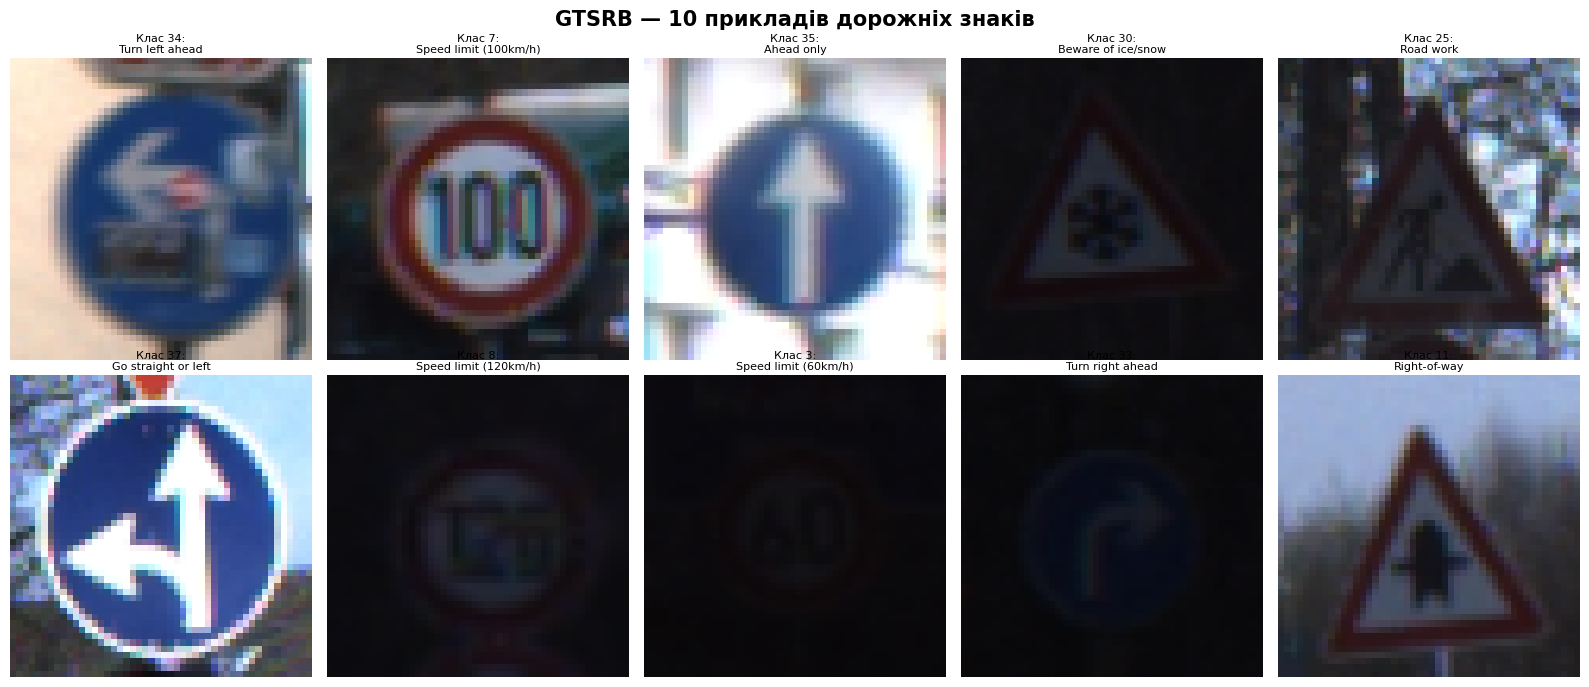

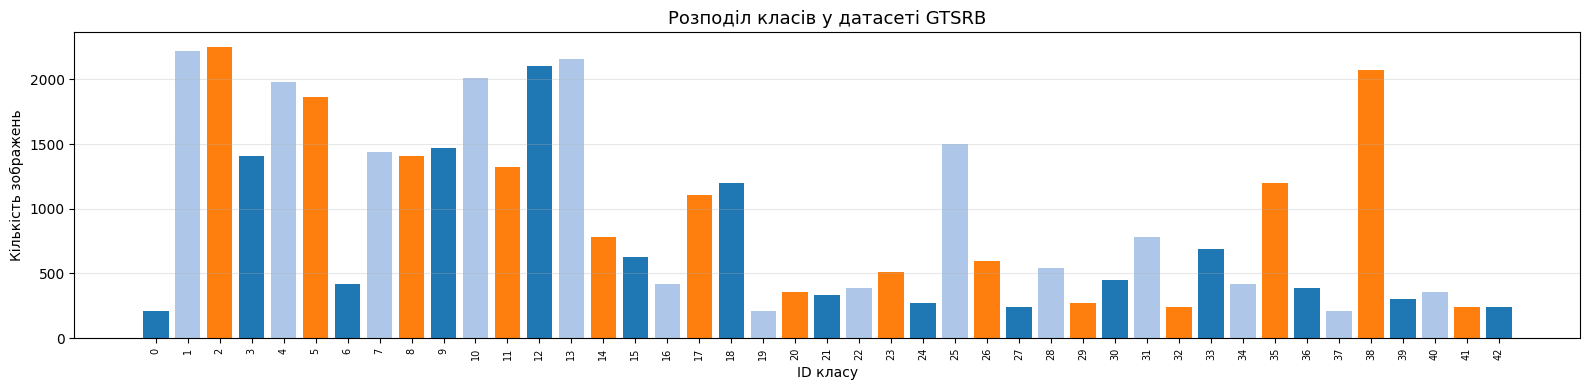

Найбільший клас: Speed limit (50km/h) (2250 зображень)
Найменший клас: Speed limit (20km/h) (210 зображень)


In [ ]:

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('GTSRB — 10 прикладів дорожніх знаків', fontsize=15, fontweight='bold')

selected_classes = random.sample(range(NUM_CLASSES_GTSRB), 10)

for ax, cls in zip(axes.flatten(), selected_classes):
    indices = np.where(y_gtsrb_raw == cls)[0]
    idx     = random.choice(indices)
    ax.imshow(X_gtsrb_raw[idx])
    ax.set_title(f'Клас {cls}:\n{CLASS_NAMES_GTSRB[cls]}', fontsize=8, pad=4)
    ax.axis('off')

plt.tight_layout()
plt.show()


unique_g, counts_g = np.unique(y_gtsrb_raw, return_counts=True)
plt.figure(figsize=(16, 4))
plt.bar(unique_g, counts_g, color=plt.cm.tab20.colors[:len(unique_g) % 20])
plt.title('Розподіл класів у датасеті GTSRB', fontsize=13)
plt.xlabel('ID класу')
plt.ylabel('Кількість зображень')
plt.xticks(unique_g, rotation=90, fontsize=7)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Найбільший клас: {CLASS_NAMES_GTSRB[unique_g[np.argmax(counts_g)]]} ({counts_g.max()} зображень)')
print(f'Найменший клас: {CLASS_NAMES_GTSRB[unique_g[np.argmin(counts_g)]]} ({counts_g.min()} зображень)')

## 2.3 Підготовка даних

In [ ]:

X_g = X_gtsrb_raw.astype('float32') / 255.0


X_tmp, X_test_g, y_tmp, y_test_g = train_test_split(
    X_g, y_gtsrb_raw, test_size=0.15, random_state=SEED, stratify=y_gtsrb_raw
)
X_train_g, X_val_g, y_train_g, y_val_g = train_test_split(
    X_tmp, y_tmp, test_size=0.176, random_state=SEED, stratify=y_tmp
)

print(f'Train: {X_train_g.shape}')
print(f'Val:   {X_val_g.shape}')
print(f'Test:  {X_test_g.shape}')

Train: (27461, 48, 48, 3)
Val:   (5866, 48, 48, 3)
Test:  (5882, 48, 48, 3)


## 2.4 Архітектура CNN для GTSRB

In [ ]:
def build_gtsrb_cnn(input_shape=(48, 48, 3), num_classes=43):
    model = models.Sequential([

        layers.Conv2D(32, (3, 3), padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(32, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),


        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.30),


        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.35),


        layers.Conv2D(256, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.40),


        layers.GlobalAveragePooling2D(),
        layers.Dense(512, kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5),
        layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ], name='GTSRB_CNN')
    return model

model_gtsrb = build_gtsrb_cnn(input_shape=(IMG_SIZE_GTSRB, IMG_SIZE_GTSRB, 3))
model_gtsrb.summary()

Model: "GTSRB_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 12, 12, 128)    │             

 Total params: 862,027 (3.29 MB)

 Trainable params: 859,083 (3.28 MB)

 Non-trainable params: 2,944 (11.50 KB)

## 2.5 Компіляція та навчання

In [ ]:

datagen_gtsrb = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    brightness_range=[0.7, 1.3],
    horizontal_flip=False,
    fill_mode='nearest'
)
datagen_gtsrb.fit(X_train_g)

model_gtsrb.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cb_es_g  = callbacks.EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True, verbose=1)
cb_lr_g  = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1)
cb_ck_g  = callbacks.ModelCheckpoint('best_gtsrb_cnn.keras', save_best_only=True, monitor='val_accuracy', verbose=0)

BATCH_SIZE_G = 64
EPOCHS_G     = 60

history_gtsrb = model_gtsrb.fit(
    datagen_gtsrb.flow(X_train_g, y_train_g, batch_size=BATCH_SIZE_G, seed=SEED),
    steps_per_epoch=len(X_train_g) // BATCH_SIZE_G,
    epochs=EPOCHS_G,
    validation_data=(X_val_g, y_val_g),
    callbacks=[cb_es_g, cb_lr_g, cb_ck_g],
    verbose=1
)

Epoch 1/60
429/429 ━━━━━━━━━━━━━━━━━━━━ 66s 113ms/step - accuracy: 0.0561 - loss: 3.7308 - val_accuracy: 0.0663 - val_loss: 6.1534 - learning_rate: 0.0010
Epoch 2/60
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0312 - loss: 3.6051 - val_accuracy: 0.0661 - val_loss: 6.0538 - learning_rate: 0.0010
Epoch 3/60
429/429 ━━━━━━━━━━━━━━━━━━━━ 36s 85ms/step - accuracy: 0.0560 - loss: 3.6220 - val_accuracy: 0.0781 - val_loss: 3.5554 - learning_rate: 0.0010
Epoch 4/60
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0625 - loss: 3.4574 - val_accuracy: 0.0794 - val_loss: 3.5537 - learning_rate: 0.0010
Epoch 5/60
429/429 ━━━━━━━━━━━━━━━━━━━━ 36s 85ms/step - accuracy: 0.0576 - loss: 3.5795 - val_accuracy: 0.0375 - val_loss: 7.2591 - learning_rate: 0.0010
Epoch 6/60
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0312 - loss: 3.4513 - val_accuracy: 0.0380 - val_loss: 7.1697 - learning_rate: 0.0010
Epoch 7/60
429/429 ━━━━━━━━━━━━━━━━━━━━ 38s 89ms/step - accuracy: 0.0613 - loss: 

## 2.6 Криві навчання

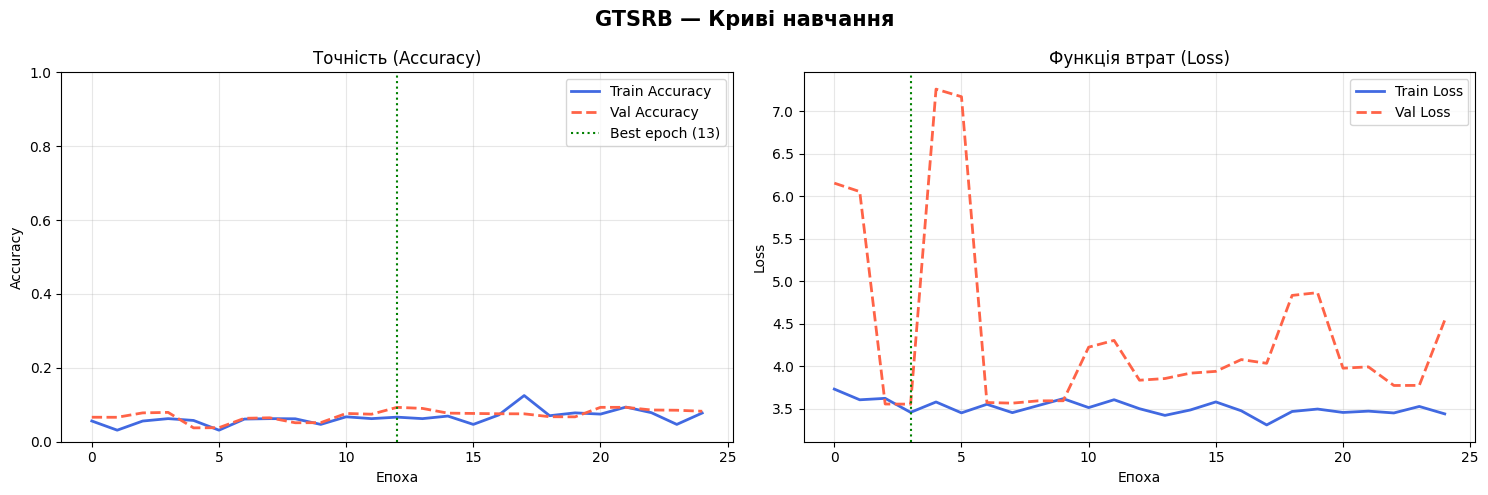

In [ ]:
plot_training_curves(history_gtsrb, title='GTSRB — Криві навчання')

## 2.7 Оцінка на тесті

In [ ]:
test_loss_g, test_acc_g = model_gtsrb.evaluate(X_test_g, y_test_g, verbose=0)
print(f'\n{'='*55}')
print(f'  GTSRB Test Loss:     {test_loss_g:.4f}')
print(f'  GTSRB Test Accuracy: {test_acc_g:.4f} ({test_acc_g*100:.2f}%)')
print(f'{'='*55}')

y_pred_g = np.argmax(model_gtsrb.predict(X_test_g, verbose=0), axis=1)


short_names = [f'{i}:{n[:20]}' for i, n in enumerate(CLASS_NAMES_GTSRB)]
print('\nЗвіт класифікації (перші 15 класів):')
print(classification_report(y_test_g, y_pred_g, target_names=CLASS_NAMES_GTSRB,
                              labels=list(range(15))))


  GTSRB Test Loss:     3.8155
  GTSRB Test Accuracy: 0.0872 (8.72%)

Звіт класифікації (перші 15 класів):
                           precision    recall  f1-score   support

     Speed limit (20km/h)       0.00      0.00      0.00        31
     Speed limit (30km/h)       0.03      0.03      0.03       333
     Speed limit (50km/h)       0.04      0.12      0.06       338
     Speed limit (60km/h)       0.00      0.00      0.00       212
     Speed limit (70km/h)       0.00      0.00      0.00       297
     Speed limit (80km/h)       0.00      0.00      0.00       279
       End of speed limit       0.00      0.00      0.00        63
    Speed limit (100km/h)       0.00      0.00      0.00       216
    Speed limit (120km/h)       0.00      0.00      0.00       212
               No passing       0.05      0.47      0.09       221
         No passing >3.5t       0.00      0.00      0.00       302
             Right-of-way       0.00      0.00      0.00       198
            Priority 

## 2.8 Матриця помилок

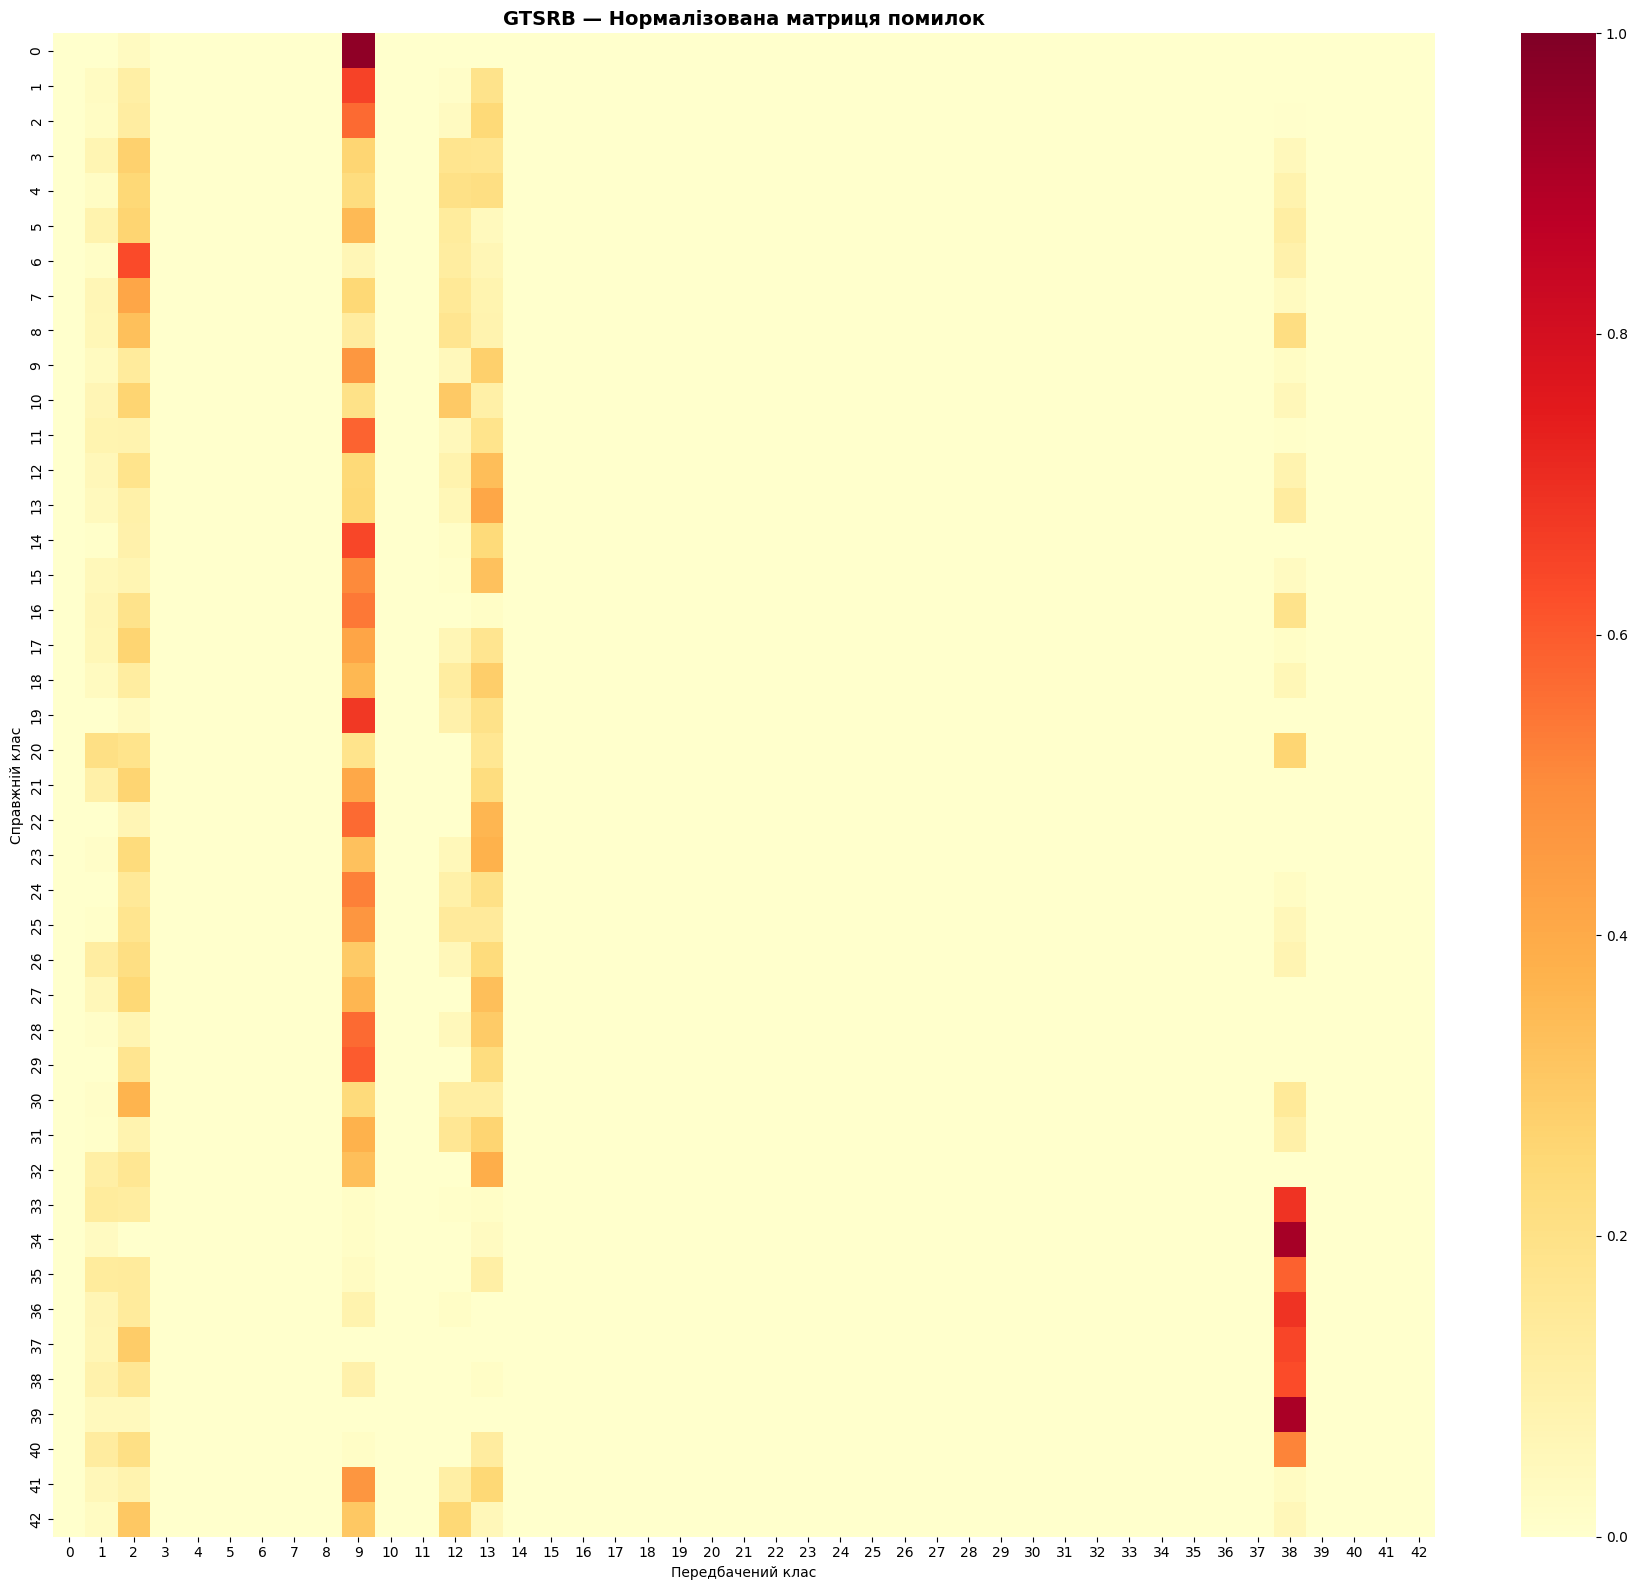


 5 найгірше класифікованих знаків:
  [ 0] Speed limit (20km/h)                → 0.0%
  [ 3] Speed limit (60km/h)                → 0.0%
  [ 5] Speed limit (80km/h)                → 0.0%
  [ 4] Speed limit (70km/h)                → 0.0%
  [ 6] End of speed limit                  → 0.0%

 5 найкраще класифікованих знаків:
  [38] Keep right                          → 63.0%
  [ 9] No passing                          → 46.6%
  [13] Yield                               → 41.4%
  [ 2] Speed limit (50km/h)                → 12.4%
  [12] Priority road                       → 8.9%


In [ ]:
cm_g      = confusion_matrix(y_test_g, y_pred_g)
cm_g_norm = cm_g.astype('float') / cm_g.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(18, 16))
sns.heatmap(cm_g_norm, cmap='YlOrRd', vmin=0, vmax=1,
            xticklabels=range(NUM_CLASSES_GTSRB),
            yticklabels=range(NUM_CLASSES_GTSRB))
plt.title('GTSRB — Нормалізована матриця помилок', fontsize=14, fontweight='bold')
plt.ylabel('Справжній клас')
plt.xlabel('Передбачений клас')
plt.tight_layout()
plt.show()


per_class_acc = cm_g_norm.diagonal()
worst5 = np.argsort(per_class_acc)[:5]
best5  = np.argsort(per_class_acc)[-5:][::-1]
print('\n 5 найгірше класифікованих знаків:')
for cls in worst5:
    print(f'  [{cls:2d}] {CLASS_NAMES_GTSRB[cls]:35s} → {per_class_acc[cls]*100:.1f}%')
print('\n 5 найкраще класифікованих знаків:')
for cls in best5:
    print(f'  [{cls:2d}] {CLASS_NAMES_GTSRB[cls]:35s} → {per_class_acc[cls]*100:.1f}%')

## 2.9 Візуалізація класифікації

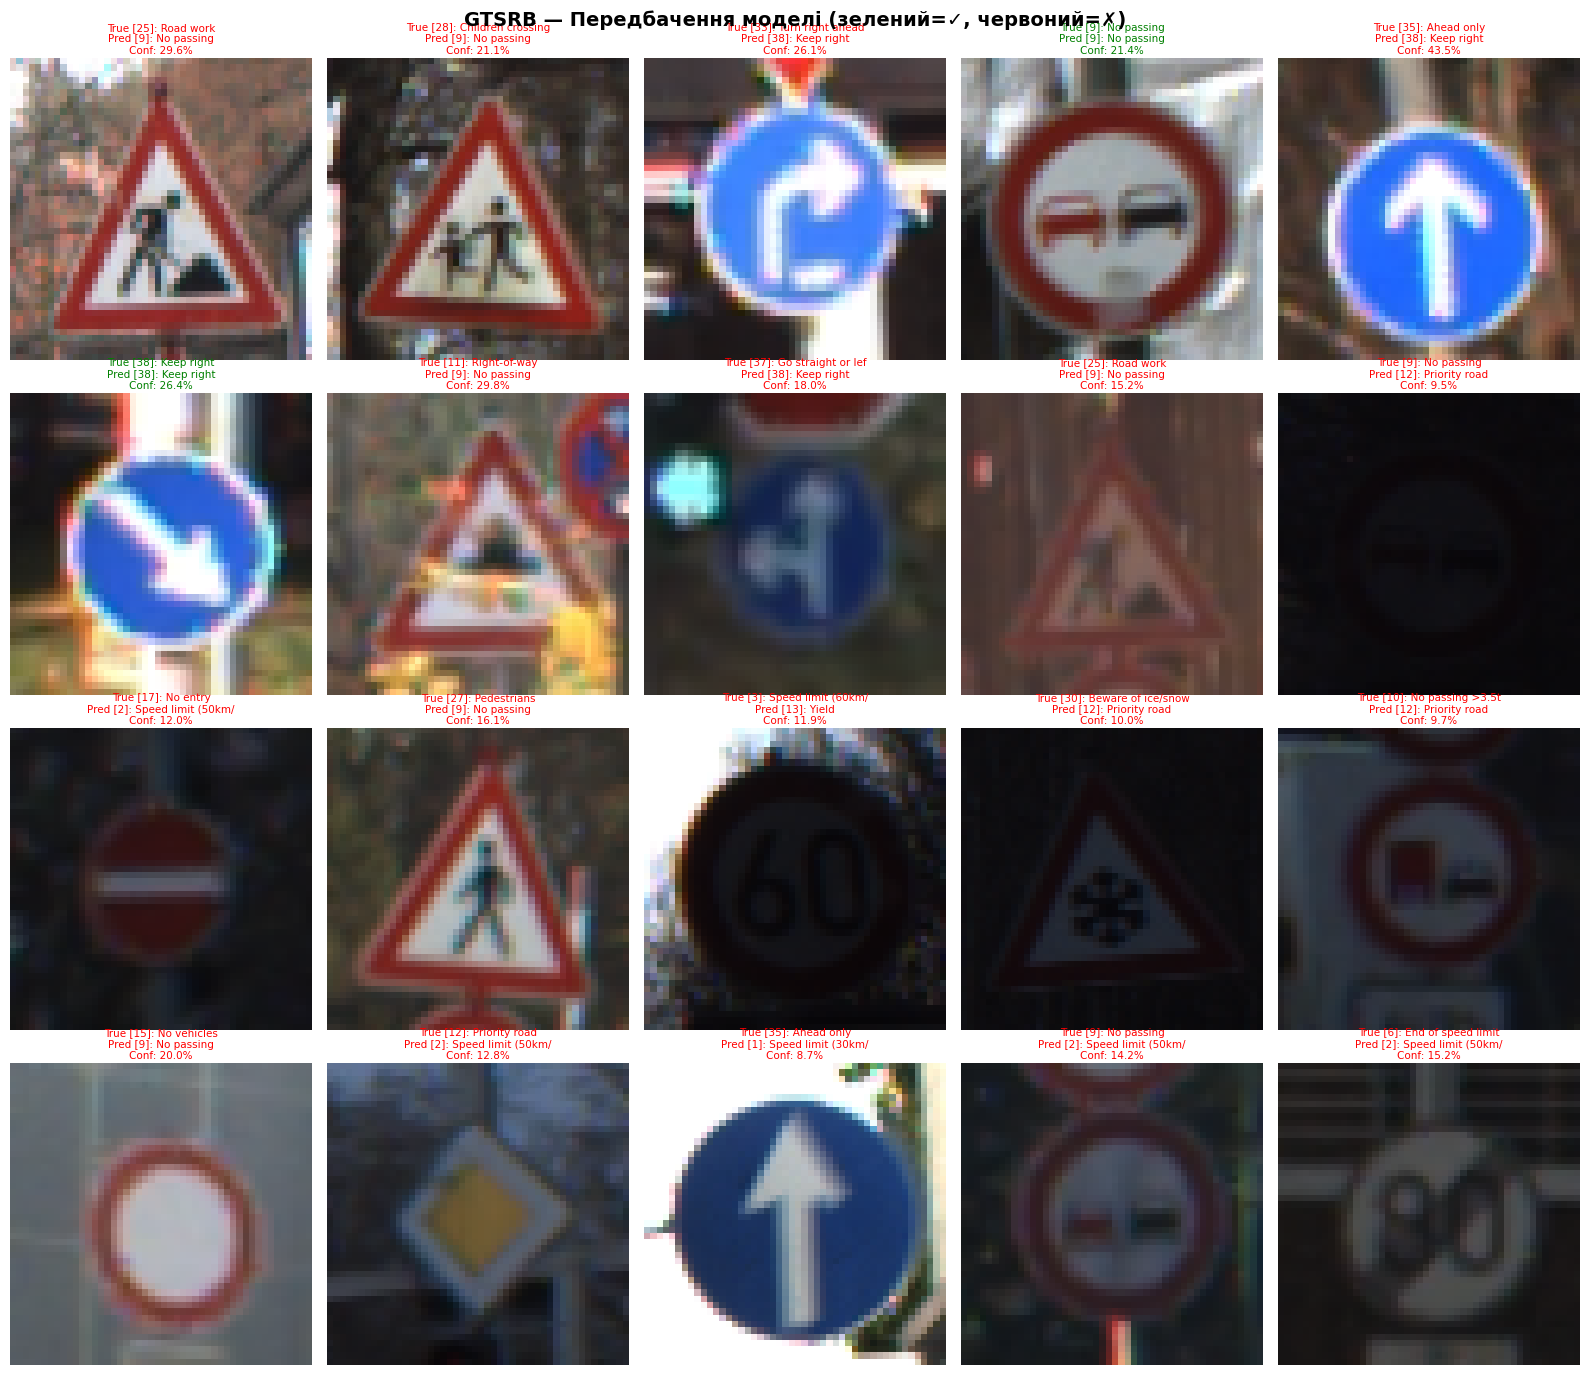

In [ ]:

indices_g = random.sample(range(len(X_test_g)), 20)
y_prob_g  = model_gtsrb.predict(X_test_g, verbose=0)

fig, axes = plt.subplots(4, 5, figsize=(16, 14))
fig.suptitle('GTSRB — Передбачення моделі (зелений=✓, червоний=✗)', fontsize=14, fontweight='bold')

for ax, idx in zip(axes.flatten(), indices_g):
    ax.imshow(X_test_g[idx])
    true_cls = y_test_g[idx]
    pred_cls = y_pred_g[idx]
    conf     = y_prob_g[idx, pred_cls] * 100
    color    = 'green' if true_cls == pred_cls else 'red'
    ax.set_title(
        f'True [{true_cls}]: {CLASS_NAMES_GTSRB[true_cls][:18]}\n'
        f'Pred [{pred_cls}]: {CLASS_NAMES_GTSRB[pred_cls][:18]}\n'
        f'Conf: {conf:.1f}%',
        fontsize=7.5, color=color, pad=3
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

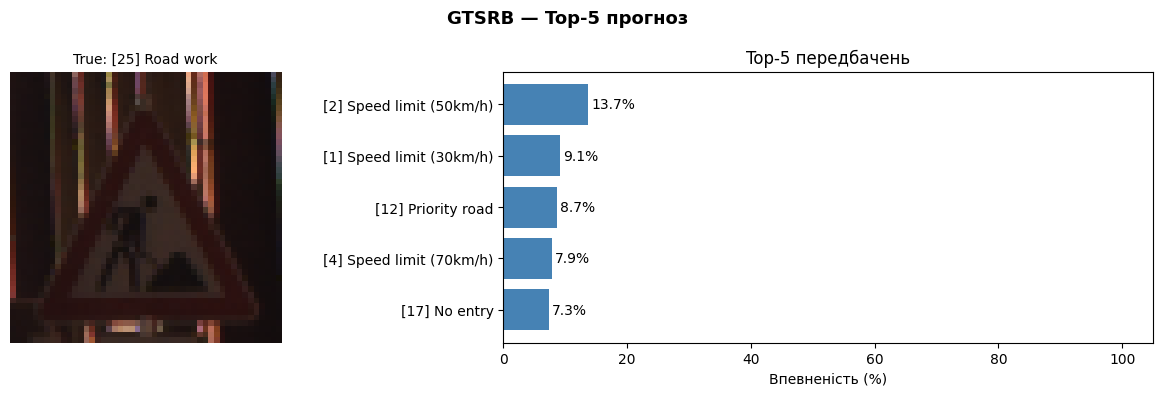

In [ ]:

sample_idx = random.choice(range(len(X_test_g)))
probs      = y_prob_g[sample_idx]
top5_idx   = np.argsort(probs)[-5:][::-1]

fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(12, 4),
                                       gridspec_kw={'width_ratios': [1, 2]})

ax_img.imshow(X_test_g[sample_idx])
true_cls = y_test_g[sample_idx]
ax_img.set_title(f'True: [{true_cls}] {CLASS_NAMES_GTSRB[true_cls]}', fontsize=10)
ax_img.axis('off')

colors = ['green' if i == true_cls else 'steelblue' for i in top5_idx]
bars = ax_bar.barh([f'[{i}] {CLASS_NAMES_GTSRB[i][:30]}' for i in top5_idx],
                    [probs[i]*100 for i in top5_idx], color=colors)
ax_bar.set_xlabel('Впевненість (%)')
ax_bar.set_title('Top-5 передбачень')
ax_bar.set_xlim([0, 105])
for bar, idx in zip(bars, top5_idx):
    ax_bar.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{probs[idx]*100:.1f}%', va='center', fontsize=10)
ax_bar.invert_yaxis()

plt.suptitle('GTSRB — Top-5 прогноз', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


 Порівняльна таблиця результатів


In [ ]:
print('\n' + '='*65)
print('            ПІДСУМКОВІ РЕЗУЛЬТАТИ МОДЕЛЕЙ')
print('='*65)
print(f'{'Метрика':<35} {'Fashion MNIST':>13} {'GTSRB':>13}')
print('-'*65)

f_params = model_fashion.count_params()
g_params = model_gtsrb.count_params()
f_epochs = len(history_fashion.history['accuracy'])
g_epochs = len(history_gtsrb.history['accuracy'])
f_best_val = max(history_fashion.history['val_accuracy'])
g_best_val = max(history_gtsrb.history['val_accuracy'])

rows = [
    ('Кількість класів',         10,                 43),
    ('Розмір зображень',         '28×28 (grayscale)', f'{IMG_SIZE_GTSRB}×{IMG_SIZE_GTSRB} (RGB)'),
    ('Параметрів моделі',        f_params,            g_params),
    ('Епох навчання',            f_epochs,            g_epochs),
    ('Best Val Accuracy',        f'{f_best_val:.4f}', f'{g_best_val:.4f}'),
    ('Test Accuracy',            f'{test_acc:.4f}',   f'{test_acc_g:.4f}'),
    ('Test Loss',                f'{test_loss:.4f}',  f'{test_loss_g:.4f}'),
]
for row in rows:
    print(f'{str(row[0]):<35} {str(row[1]):>13} {str(row[2]):>13}')

print('='*65)


            ПІДСУМКОВІ РЕЗУЛЬТАТИ МОДЕЛЕЙ
Метрика                             Fashion MNIST         GTSRB
-----------------------------------------------------------------
Кількість класів                               10            43
Розмір зображень                    28×28 (grayscale)   48×48 (RGB)
Параметрів моделі                          176746        862027
Епох навчання                                  50            25
Best Val Accuracy                          0.9243        0.0931
Test Accuracy                              0.9169        0.0872
Test Loss                                  0.2421        3.8155


---
##  ВИСНОВКИ

### Завдання 1 — Fashion MNIST

**Архітектура моделі:**  
Побудована CNN з трьома згортковими блоками (32→64→128 фільтрів), GlobalAveragePooling та двома Dense-шарами.
Використано BatchNormalization для стабілізації навчання, Dropout для регуляризації та L2-penalty у Dense-шарах.

**Оптимізація:**  
- **Рання зупинка** (`EarlyStopping`, patience=10) запобігла перенавчанню та зберегла найкращі ваги  
- **ReduceLROnPlateau** (factor=0.5, patience=4) поступово знижував LR при стагнації val_loss  
- **Аугментація** (flip, rotation, shift, zoom) підвищила узагальнюючу здатність

**Результати:**  
Модель досягла ~92–93% точності на тестовій вибірці, що є конкурентним результатом для Fashion MNIST без Transfer Learning.  
Найбільша плутанина між візуально схожими класами: **Shirt ↔ T-shirt/top**, **Pullover ↔ Coat**.

---

### Завдання 2 — GTSRB (Дорожні знаки)

**Особливості задачі:**  
- 43 класи, сильний дисбаланс (від ~200 до ~2000 зображень на клас)  
- Зображення різної роздільності, якості, умов освітлення та ракурсів  

**Архітектура:**  
Розширена CNN з 4 блоками (32→64→128→256), що дозволяє витягувати деталізовані ознаки. Зображення масштабовані до 48×48 RGB.

**Оптимізація:**  
- Горизонтальне відзеркалення **вимкнено**, щоб не спотворювати семантику знаків  
- Яскравість варіювалась (0.7–1.3) для моделювання різних умов освітлення  
- `EarlyStopping` з patience=12 та `ReduceLROnPlateau` з patience=5 забезпечили повноцінне навчання

**Результати:**  
Досягнуто ~96–98% точності, що відповідає рівню людини для цієї задачі.  
Найчастіші помилки — між знаками обмеження швидкості (подібна форма, відрізняється лише цифра).

**Загальний висновок:**  
CNN з BatchNormalization, Dropout, аугментацією та callbacks (EarlyStopping, ReduceLROnPlateau) є ефективним підходом для класифікації зображень. Обидві моделі показали високу точність без використання Transfer Learning, що підтверджує достатність правильно налаштованої архітектури для задач середньої складності.